# Studio 1 — Retirement Monte Carlo: simulate the future you can't observe 🎲📈

**OPIM 5641 · Business Decision Modeling**

Name: Kapil Kumar Sharma

Husky CT: apl25002

Date: 09-16-2026

## 1 · One possible future

Save $6,000 a year, earn a random return each year. One `for` loop, one life.

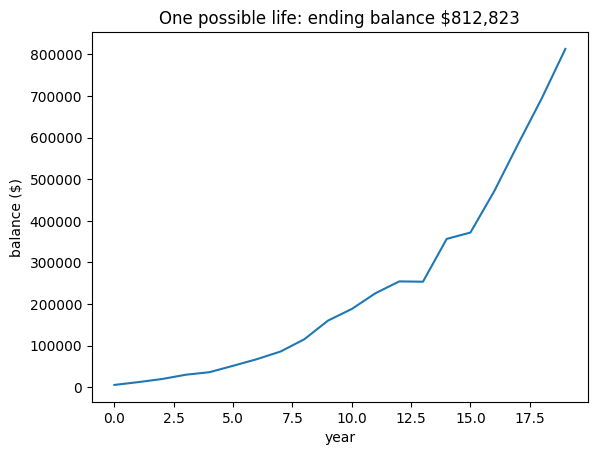

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(5641)   # same seed, same story, every run

years = 20
contribution = 6_000

balance = 0.0
path = []
for year in range(years):
    r = np.random.normal(0.07, 0.20)          # a made-up 'typical' stock year: mean 7%, sd 20%
    balance = balance * (1 + r) + contribution
    path.append(balance)

plt.plot(path)
plt.title(f'One possible life: ending balance ${balance:,.0f}')
plt.xlabel('year'); plt.ylabel('balance ($)');

Run that cell a few times (change the seed). Every run ends somewhere different —
so **one run tells you almost nothing**. That's the whole reason Monte Carlo exists.

## 2 · Ten thousand futures

Same loop, wrapped in another loop. Now we get a **distribution** of endings — and
percentiles we can actually plan around.

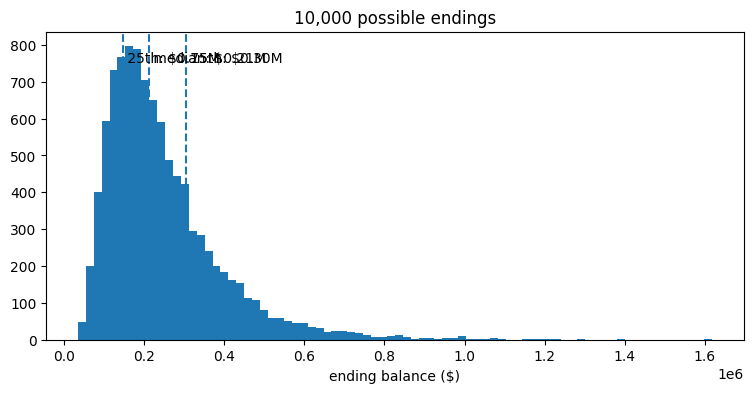

In [9]:
n_sims = 10_000
endings = np.zeros(n_sims)
all_paths = np.zeros((n_sims, years))

for sim in range(n_sims):
    balance = 0.0
    for year in range(years):
        r = np.random.normal(0.07, 0.20)
        balance = balance * (1 + r) + contribution
        all_paths[sim, year] = balance
    endings[sim] = balance

lo, med, hi = np.percentile(endings, [25, 50, 75])
plt.figure(figsize=(9, 4))
plt.hist(endings, bins=80)
for v, name in [(lo, '25th'), (med, 'median'), (hi, '75th')]:
    plt.axvline(v, ls='--')
    plt.text(v, plt.ylim()[1]*0.9, f' {name}: ${v/1e6:,.2f}M')
plt.title('10,000 possible endings')
plt.xlabel('ending balance ($)');

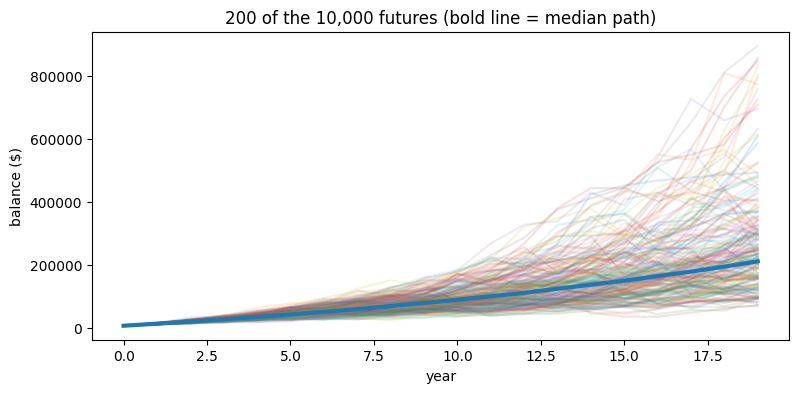

In [10]:
# The spaghetti plot — every future at once (plot a sample of 200)
plt.figure(figsize=(9, 4))
plt.plot(all_paths[:200].T, alpha=0.15)
plt.plot(np.median(all_paths, axis=0), lw=3)
plt.title('200 of the 10,000 futures (bold line = median path)')
plt.xlabel('year'); plt.ylabel('balance ($)');

**Answer with a probability, not a number** (this is the Assignment 1 recipe):

Calculating the proportion of simulations that satisfy the condition.

In [11]:
target = 1_000_000
print(f'P(ending >= $1M) = {(endings >= target).mean():.1%}')
print(f'P(ending <  $500k) = {(endings < 500_000).mean():.1%}')

P(ending >= $1M) = 0.2%
P(ending <  $500k) = 94.2%


In [13]:
target = 10_000_000
print(f'P(ending >= $10M) = {(endings >= target).mean():.1%}')
print(f'P(ending <  $5M) = {(endings < 5_000_000).mean():.1%}')

P(ending >= $10M) = 0.0%
P(ending <  $5M) = 100.0%


## 3 · The twist: sample from *real* history

`normal(0.07, 0.20)` is a modeling choice — and it's wrong in an important way.
Instead, **bootstrap**: each simulated year, draw an *actual* annual S&P 500 total return
(1928–2025, dividends included) at random, with replacement. Same code shape. Different sampler. Fatter tails.

98 years of real returns
best year:  {'year': 1954.0, 'sp500_total_return': 0.525633}
worst year: {'year': 1931.0, 'sp500_total_return': -0.438375}


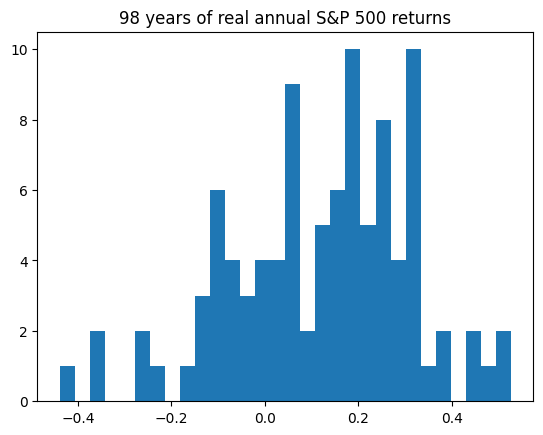

In [16]:
url = 'https://raw.githubusercontent.com/k-git-uconn/Studio1-BDM-F26/main/studio1/sp500_annual_returns.csv'
sp = pd.read_csv(url)
returns_history = sp['sp500_total_return'].values
print(len(returns_history), 'years of real returns')
print('best year: ', sp.loc[sp.sp500_total_return.idxmax()].to_dict())
print('worst year:', sp.loc[sp.sp500_total_return.idxmin()].to_dict())
plt.hist(returns_history, bins=30)
plt.title('98 years of real annual S&P 500 returns');

Lets use historical annual S&P 500 total returns as the empirical distribution and sample one return with replacement for each simulated year.

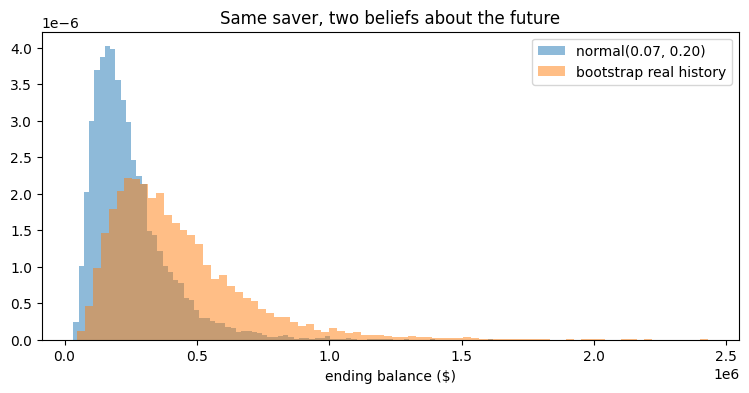

In [17]:
endings_boot = np.zeros(n_sims)
for sim in range(n_sims):
    balance = 0.0
    rs = sp['sp500_total_return'].sample(n=years, replace=True).values   # <-- THE line: resample real history
    for r in rs:
        balance = balance * (1 + r) + contribution
    endings_boot[sim] = balance

plt.figure(figsize=(9, 4))
plt.hist(endings, bins=80, alpha=0.5, label='normal(0.07, 0.20)', density=True)
plt.hist(endings_boot, bins=80, alpha=0.5, label='bootstrap real history', density=True)
plt.legend()
plt.title('Same saver, two beliefs about the future')
plt.xlabel('ending balance ($)');

In [18]:
for name, e in [('normal', endings), ('bootstrap', endings_boot)]:
    print(f'{name:>9}:  median ${np.median(e)/1e6:.2f}M   P(>=$1M) {(e>=1e6).mean():.1%}   P(<$500k) {(e<5e5).mean():.1%}')


   normal:  median $0.21M   P(>=$1M) 0.2%   P(<$500k) 94.2%
bootstrap:  median $0.37M   P(>=$1M) 3.5%   P(<$500k) 71.0%


**Discuss:** the two histograms disagree. Which belief about the future would you plan your life around, and why?
What does the bootstrap capture that the normal distribution can't? *(Hint: 1931 was -43.8%. How many sd's below a
mean-7%/sd-20% normal is that?)*

## Wrap 🧵

- **Explore what you have. Simulate what you don't.** One evening, both halves.
- Assignment 1 asks you to do exactly this on a dataset **you** choose: estimate the uncertain input
  from the data you have, then simulate the future you don't have.
- Before you leave: File → **Save a copy in GitHub** → `opim5641-work`. Second time tonight — it's a habit now.

Comment: I would plan around the bootstrap distribution, because it uses the actual historical S&P 500 total-return distribution rather than assuming returns are normally distributed.

For example, the 1931 return of -43.8% is about 2.54 standard deviations below a normal distribution with a 7% mean and 20% standard deviation. The bootstrap captures this type of extreme historical event directly because it can resample the actual observation.

The normal distribution is useful as a simple modeling assumption, but it imposes a bell-shaped distribution and can underrepresent the probability of extreme outcomes. The bootstrap captures the fatter tails and unusual historical returns present in the actual data. For long-term financial planning, I would therefore prefer the bootstrap as a more realistic representation of the range of outcomes observed historically, while still recognizing that future market behavior may differ from the historical period.